In [ ]:
import numpy as np 
import pandas as pd
from sklearn.decomposition import PCA
from MakeDataset import get_data
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
# config retina
%config InlineBackend.figure_format = 'retina'

import warnings
warnings.filterwarnings('ignore')

In [ ]:
X_train, X_test, y_train, y_test = get_data()
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(126, 500, 3) (126,)
(54, 500, 3) (54,)


### TASK 1

Plotting the waveform for one sample data from each activity class

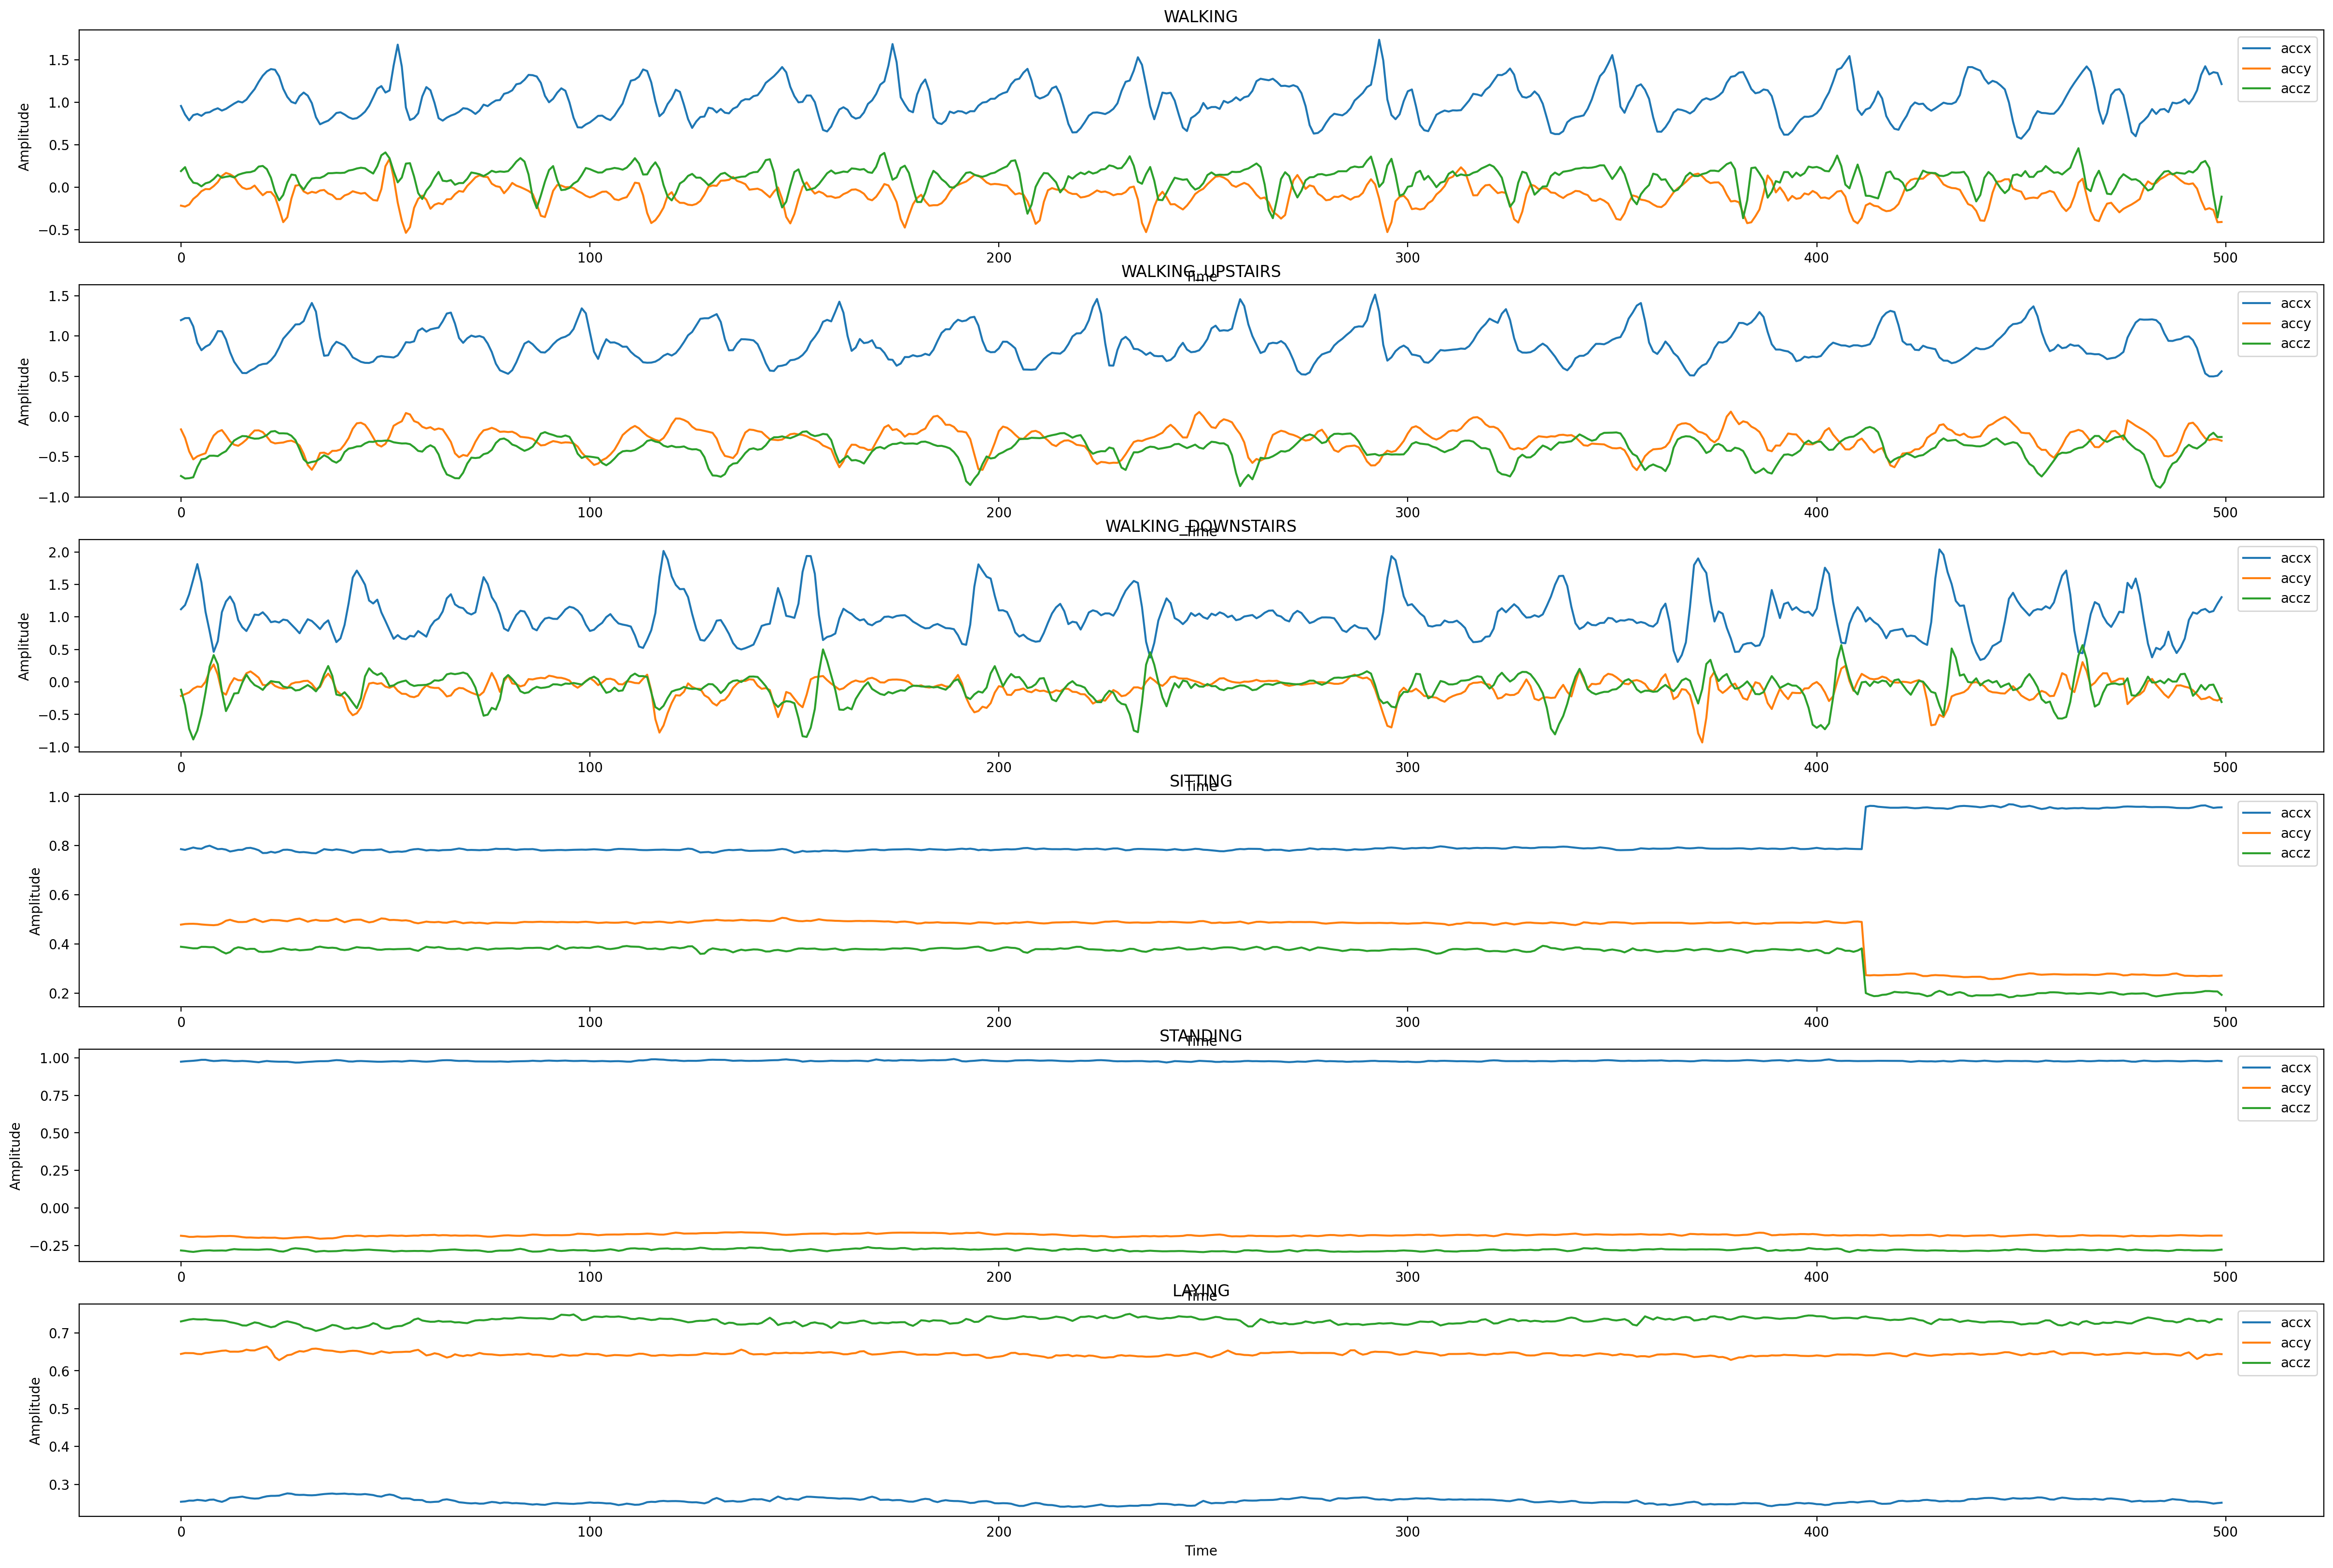

In [ ]:
y_train.shape
dic= {1:"WALKING",2:"WALKING_UPSTAIRS",3:"WALKING_DOWNSTAIRS",4:"SITTING",5:"STANDING",6:"LAYING"}
lis=["accx","accy","accz"]


fig, axes= plt.subplots(6,1,figsize=(30,20))
for i in range(1,7):
    index=np.where(y_train==i)[0]
    sample=X_train[index[0]]
    for j in range(len(lis)):
        axes[i-1].plot(sample[:,j],label=lis[j])
    axes[i - 1].set_title(dic[i])
    axes[i - 1].set_xlabel('Time')
    axes[i - 1].set_ylabel('Amplitude')
    axes[i-1].legend()
plt.show()    

Finding linear acceleration for each activity

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_series = pd.Series(y_train)
y_train_labels = y_train_series.replace({1: 'Walking', 2: 'WALKING_UPSTAIRS', 3: 'WALKING_DOWNSTAIRS', 4: 'SITTING', 5: 'STANDING', 6: 'LAYING'})

linear_acceleration = np.sqrt((np.sum(np.square(X_train), axis=-1)))



###  Visualize the data using PCA.

Use PCA (Principal Component Analysis) on Total Acceleration $(acc_x^2+acc_y^2+acc_z^2)$ to compress the acceleration timeseries into two features and plot a scatter plot to visualize different class of activities.  

Perform PCA to obtain two features from the features provided by the dataset . Plot a scatter plot to visualize different class of activities.
 

* Visualising PCA on total acceleration data

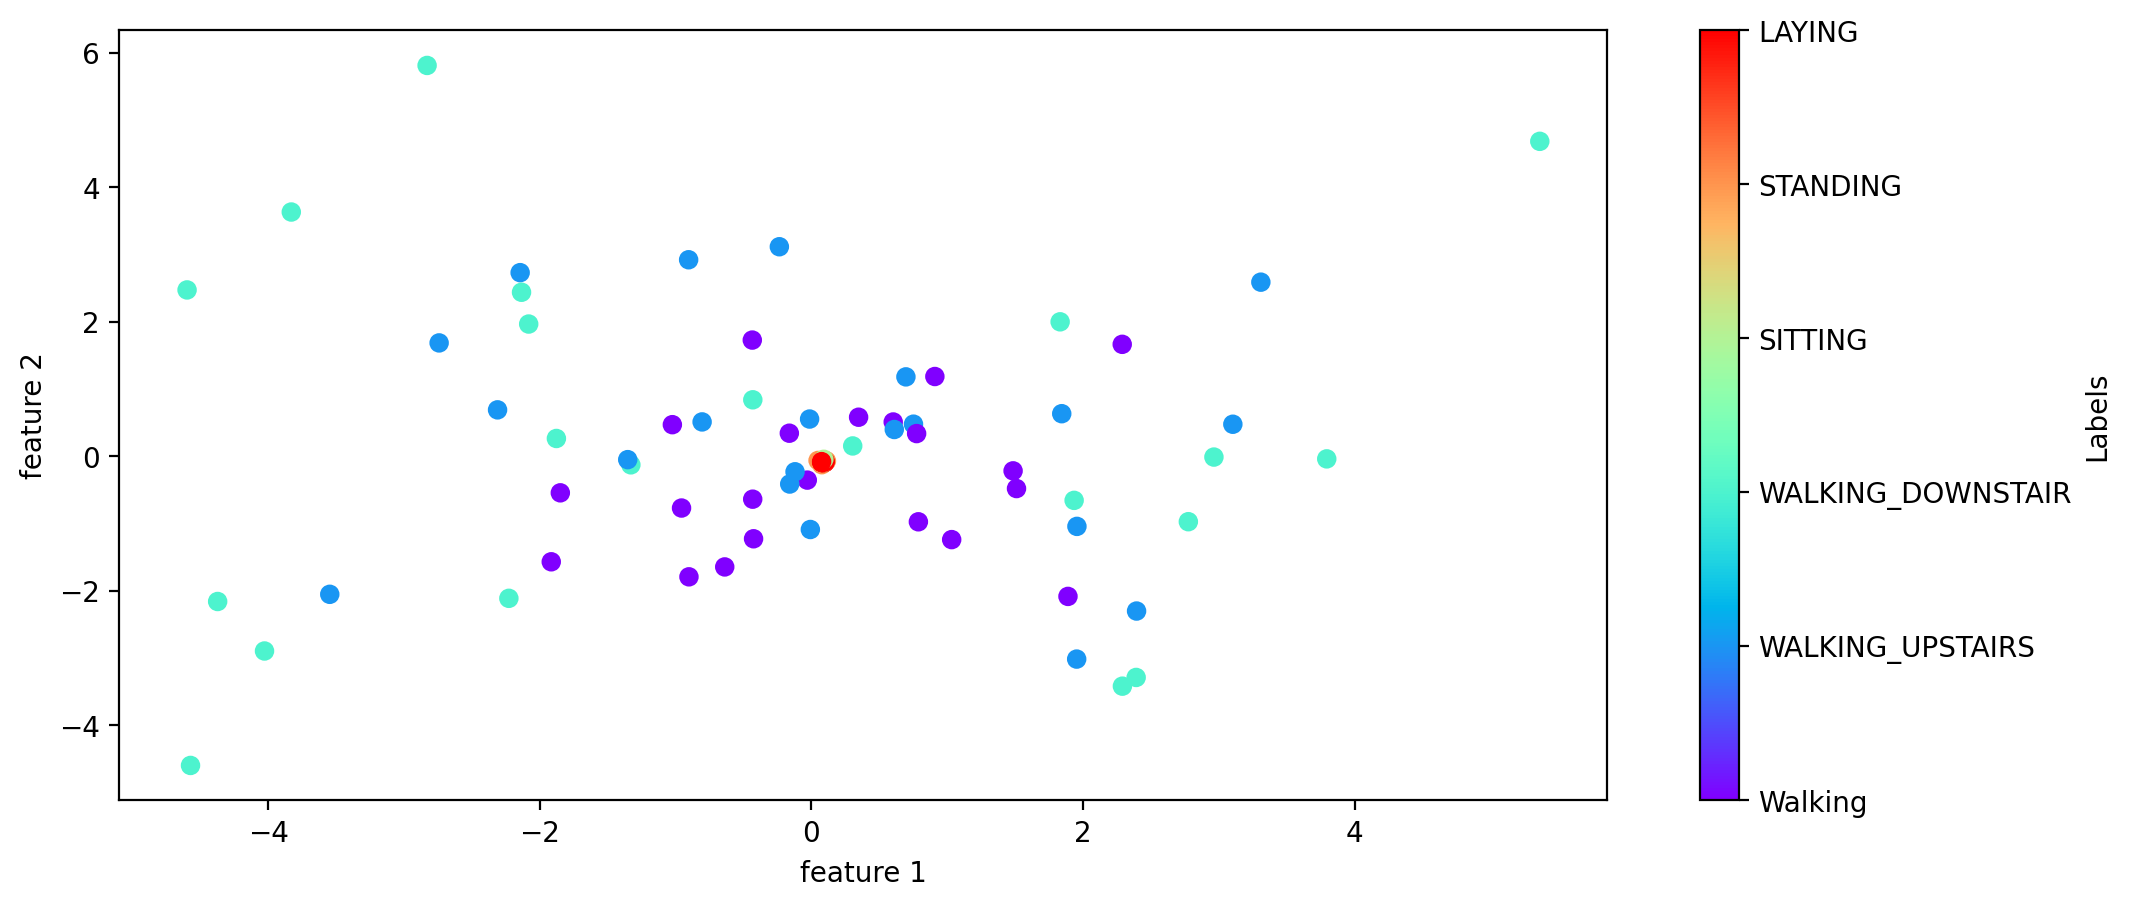

In [ ]:
total_linear_acceleration_x_train = np.sqrt(np.sum(np.square(X_train), axis=-1))
total_linear_acceleration_x_train.shape
pca = PCA(n_components=2)
pca_of_X_train = []

pca_of_X_train = pca.fit_transform(total_linear_acceleration_x_train)

pca_of_X_train = np.array(pca_of_X_train)
pca_of_X_train.shape
fig, ax = plt.subplots(1,1, figsize=(12,5))

label_names = np.array(['Walking', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIR','SITTING', 'STANDING', 'LAYING'])

scatter = ax.scatter(*pca_of_X_train.T, c=y_train,  cmap='rainbow')
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks([1, 2, 3, 4, 5, 6])  # Set the ticks to match y_train values
cbar.set_ticklabels(label_names)     # Set the tick labels to the label names
cbar.set_label("Labels")

plt.show()

* Use TSFEL and then use PCA

In [ ]:
import tsfel
x_train_flatten_raw_data = np.sqrt(np.sum(np.square(X_train), axis=-1))
x_test_flatten_raw_data = np.sqrt(np.sum(np.square(X_test), axis=-1))
x_train_flatten_raw_data.shape

(126, 500)

In [ ]:
def get_tsfel_features(X):

    imp_features = ["_Absolute energy", "_Area under the curve", "_Autocorrelation",
                    "_Centroid", "_Entropy", "_FFT mean coefficient_1", "_Interquartile range",
                    "_Kurtosis", "_Mean", "_Median", "_Skewness", "_Variance"]
    
    cfg_file = tsfel.get_features_by_domain()                                                 # If no argument is passed retrieves all available features
    tsfel_train_df = tsfel.time_series_features_extractor(cfg_file, pd.DataFrame(X.T))
    
    df = pd.DataFrame()
    for i in range(len(X)):
        for f in imp_features:
            df[str(i)+f] = tsfel_train_df[str(i)+f]

    df_new = pd.DataFrame(columns=imp_features)
    for f in imp_features:
        for i in range(len(X)):
            df_new.at[i, f] = df[str(i)+f].iloc[0]

    return df_new

x_train_tsfel_extracted_data = get_tsfel_features(x_train_flatten_raw_data)
x_test_tsfel_extracted_data = get_tsfel_features(x_test_flatten_raw_data)

*** Feature extraction started ***



*** Feature extraction finished ***
*** Feature extraction started ***



*** Feature extraction finished ***


In [ ]:
x_train_tsfel_extracted_data

,_Absolute energy,_Area under the curve,_Autocorrelation,_Centroid,_Entropy,_FFT mean coefficient_1,_Interquartile range,_Kurtosis,_Mean,_Median,_Skewness,_Variance
0,574.758725,5.221582,5.0,2.493721,1.0,0.000018,0.303099,-0.197653,1.046419,1.012658,0.539466,0.054525
1,508.200966,5.03072,2.0,2.4948,1.0,0.0,0.004942,0.507117,1.00816,1.008337,-0.365614,0.000015
2,533.943188,5.156593,2.0,2.494892,1.0,0.0,0.003467,1.107387,1.033381,1.033415,0.253971,0.00001
3,571.486972,5.201674,5.0,2.509602,1.0,0.000012,0.286852,0.907282,1.042181,0.990316,1.149771,0.056833
4,577.271579,5.211831,6.0,2.493743,1.0,0.000079,0.404873,-0.778099,1.043884,1.003608,0.56317,0.06485
...,...,...,...,...,...,...,...,...,...,...,...,...
121,573.609794,5.235266,4.0,2.472002,1.0,0.000021,0.379555,-1.104459,1.049362,1.05275,-0.023164,0.046058
122,504.323961,5.010711,9.0,2.4773,1.0,0.000176,0.014861,9.439238,1.004159,1.000366,0.970827,0.000313
123,508.112505,5.030264,2.0,2.496068,1.0,0.000003,0.005275,0.60037,1.008071,1.00812,0.006296,0.000017
124,579.356113,5.228764,5.0,2.502142,1.0,0.000222,0.287267,0.379988,1.047328,0.997932,0.94017,0.061817


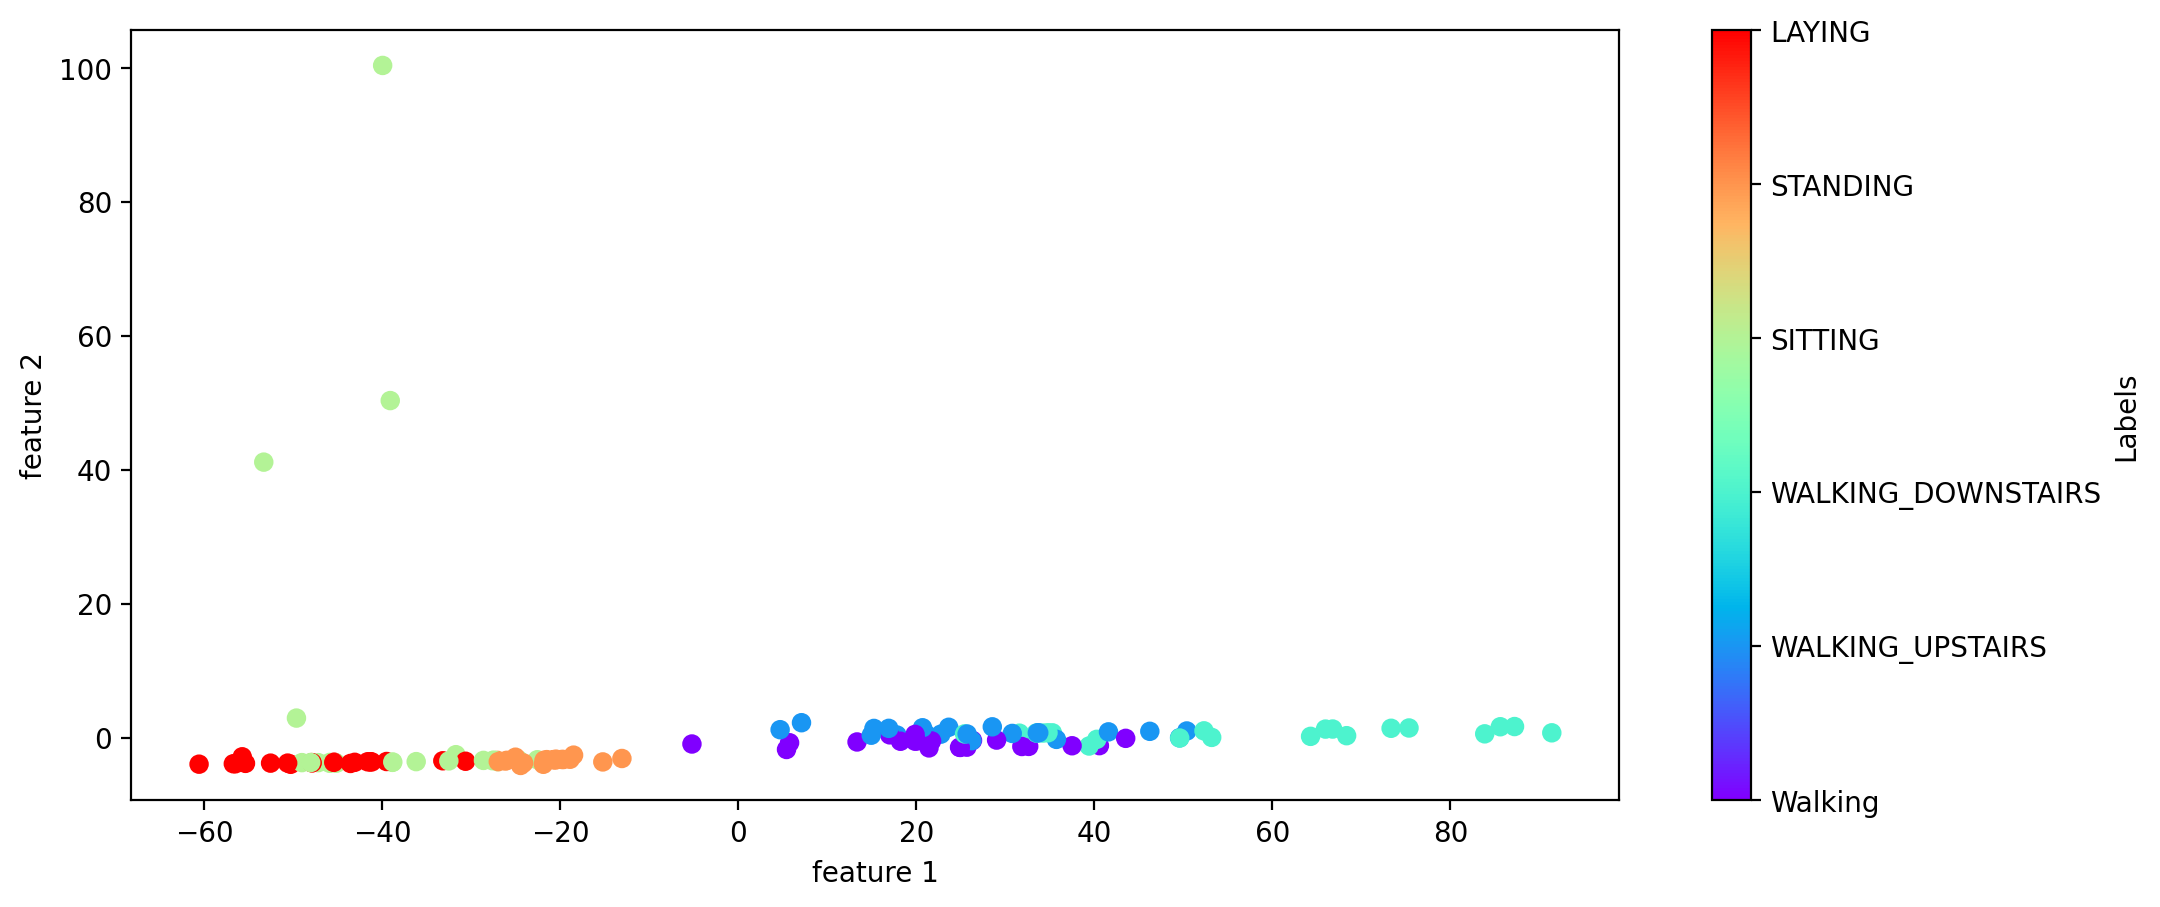

In [ ]:
pca_tsfel = PCA(n_components=2)

transformed_x_train_dataset = pca_tsfel.fit_transform(x_train_tsfel_extracted_data)
transformed_x_train_dataset.shape

fig, ax = plt.subplots(1,1, figsize=(12,5))

label_names = np.array(['Walking', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING'])

scatter = ax.scatter(*transformed_x_train_dataset.T, c=y_train, cmap='rainbow')
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks([1, 2, 3, 4, 5, 6])  # Set the ticks to match y_train values
cbar.set_ticklabels(label_names)     # Set the tick labels to the label names
cbar.set_label("Labels")

plt.show()

* Correlation matrix of TSFEL data

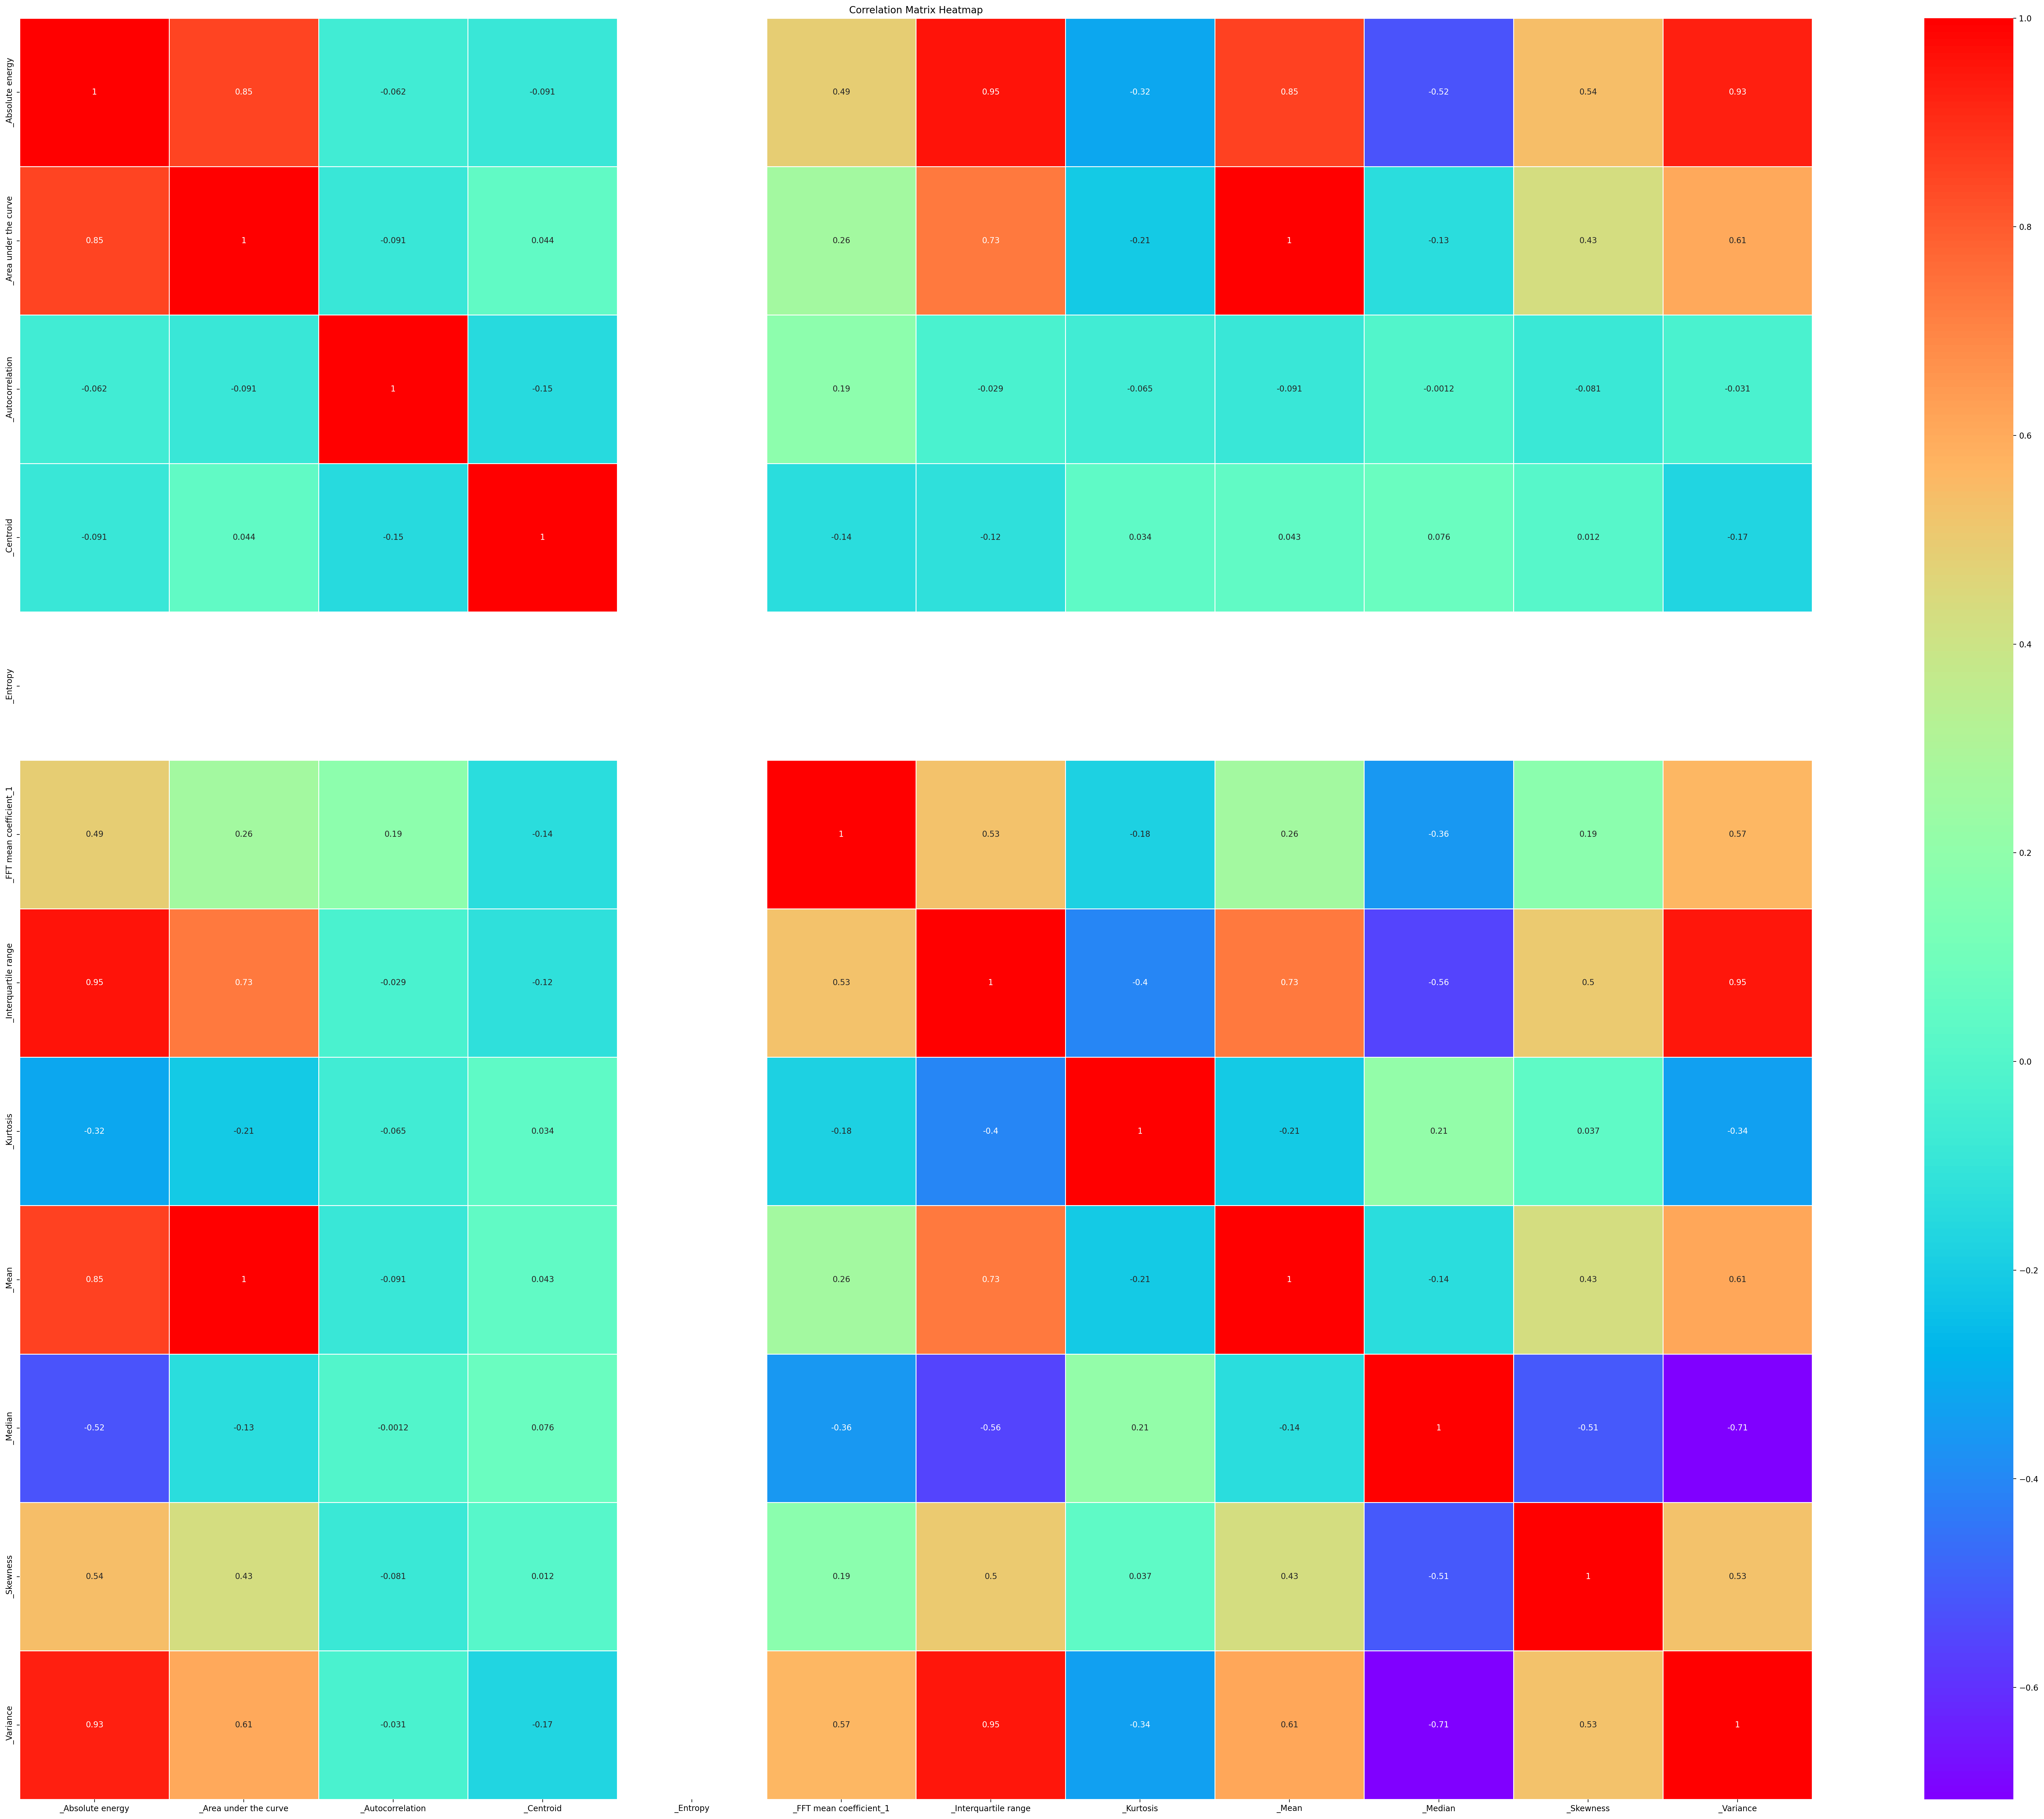

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = x_train_tsfel_extracted_data.corr()

plt.figure(figsize=(50, 40))
sns.heatmap(corr_matrix, annot=True, cmap='rainbow', linewidths=0.5)

plt.title('Correlation Matrix Heatmap')
plt.show()

* Visualising PCA on feature Dataset

In [ ]:
import os
import pandas  as pd
train_path = "./UCI HAR Dataset/train"
groups = pd.read_csv(os.path.join(train_path,"subject_train.txt"),delim_whitespace=True,header=None)
x_train_dataset= pd.read_csv(os.path.join(train_path,"X_train.txt"),delim_whitespace=True,header=None)
y_train_dataset= pd.read_csv(os.path.join(train_path,"y_train.txt"),delim_whitespace=True,header=None)
test_path = "./UCI HAR Dataset/test"
x_test_dataset= pd.read_csv(os.path.join(test_path,"X_test.txt"),delim_whitespace=True,header=None)
y_test_dataset= pd.read_csv(os.path.join(test_path,"y_test.txt"),delim_whitespace=True,header=None)

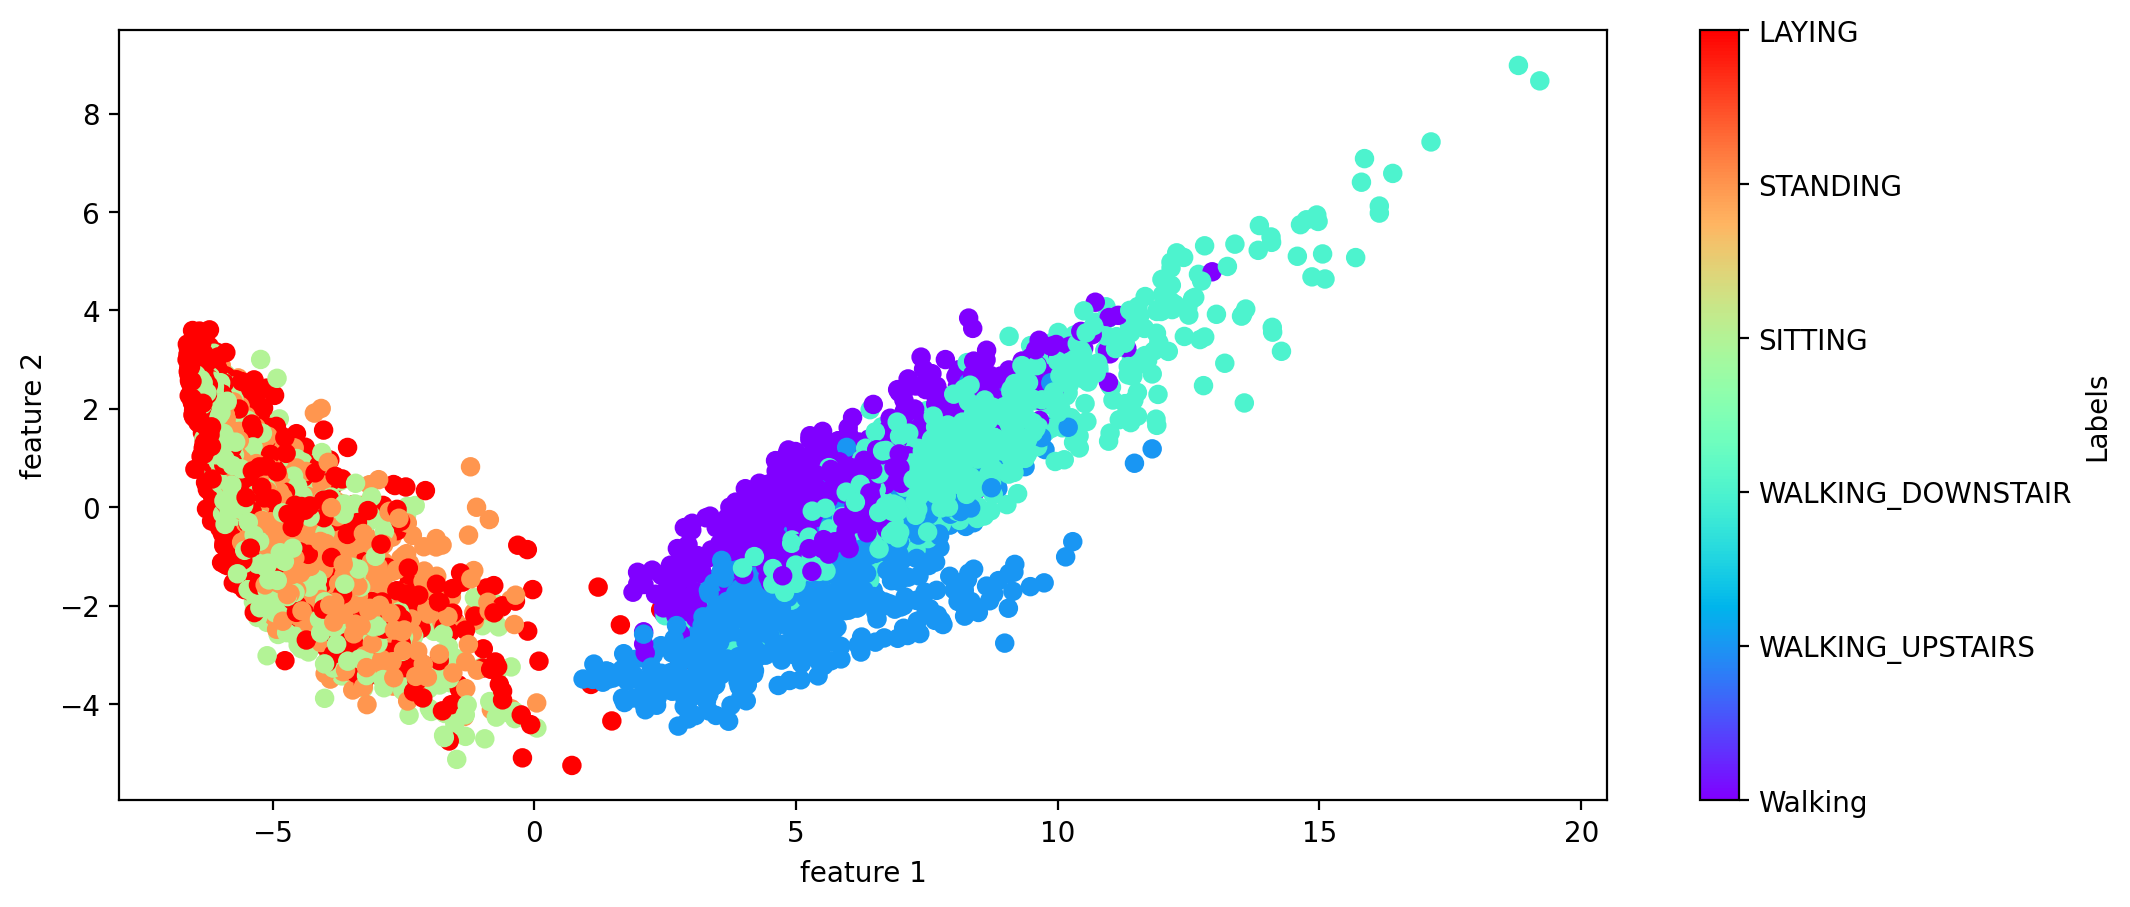

In [ ]:
from sklearn.decomposition import PCA

pca_dataset = PCA(n_components=2)

transformed_x_train_dataset = pca_dataset.fit_transform(x_train_dataset)
transformed_x_train_dataset.shape
fig, ax = plt.subplots(1,1, figsize=(12,5))

label_names = np.array(['Walking', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIR','SITTING', 'STANDING', 'LAYING'])

scatter = ax.scatter(*transformed_x_train_dataset.T, c=y_train_dataset, cmap='rainbow')
ax.set_xlabel("feature 1")
ax.set_ylabel("feature 2")

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_ticks([1, 2, 3, 4, 5, 6])  # Set the ticks to match y_train values
cbar.set_ticklabels(label_names)     # Set the tick labels to the label names
cbar.set_label("Labels")

plt.show()

### Task 2

####  Use Sklearn Library to train Decision Tress. 
    
* Train a decision tree model using the raw accelerometer data. Report the accuracy, precision, recall and confusion matrix of the model.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.model_selection import LeaveOneGroupOut

Accuracy: 0.5925925925925926
              precision    recall  f1-score   support

           1       0.50      0.44      0.47         9
           2       0.57      0.44      0.50         9
           3       0.50      0.44      0.47         9
           4       0.62      0.56      0.59         9
           5       0.75      1.00      0.86         9
           6       0.55      0.67      0.60         9

    accuracy                           0.59        54
   macro avg       0.58      0.59      0.58        54
weighted avg       0.58      0.59      0.58        54



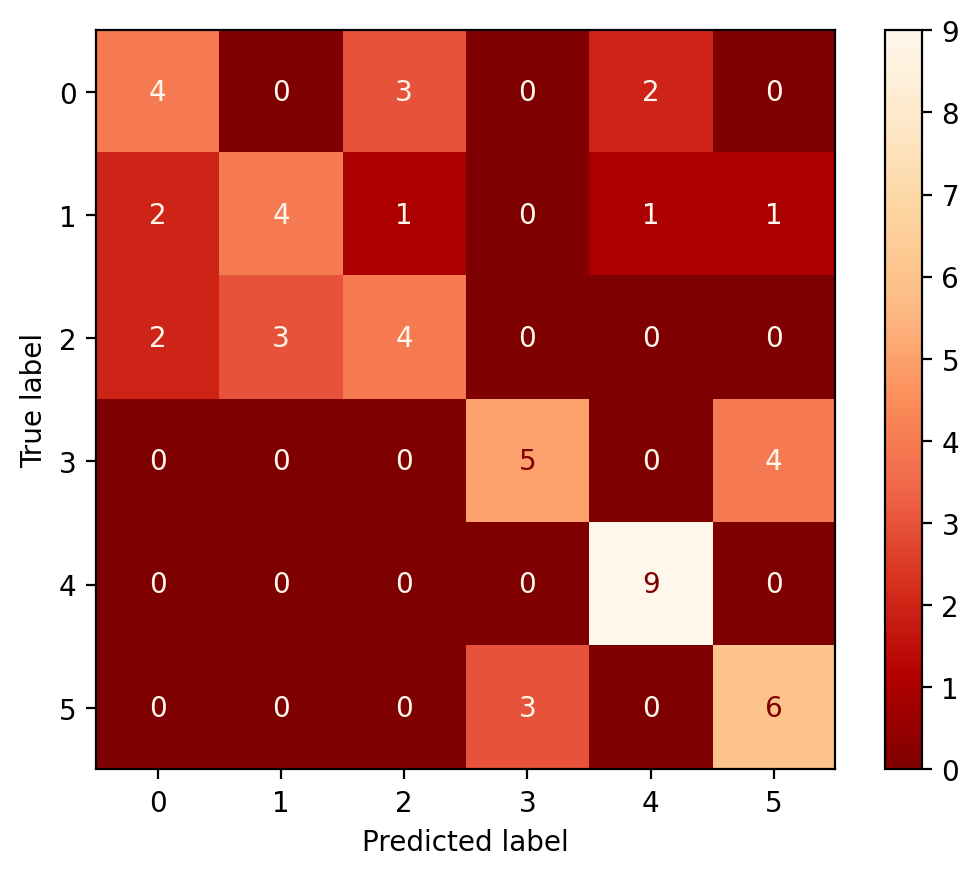

In [ ]:
clf_for_raw_data=DecisionTreeClassifier()

X_train_linear_acceleration = np.sqrt(np.sum(np.square(X_train), axis=-1))
y_train_linear_acceleration = y_train.reshape(-1)

X_test_linear_acceleration = np.sqrt(np.sum(np.square(X_test), axis=-1))
y_test_linear_acceleration =y_test.reshape(-1)

clf_for_raw_data.fit(X_train_linear_acceleration, y_train_linear_acceleration)
y_pred=clf_for_raw_data.predict(X_test_linear_acceleration)

accuracy=accuracy_score(y_test_linear_acceleration, y_pred)
print(f"Accuracy: {accuracy}")

cm = confusion_matrix(y_test_linear_acceleration, y_pred)
cm_display = ConfusionMatrixDisplay(cm).plot(values_format='d', cmap='OrRd_r', ax=plt.gca())
print(classification_report(y_test_linear_acceleration, y_pred))

* Train a decision tree model using the features obtained by TSFEL. Report the accuracy, precision, recall and confusion matrix of the mode

Accuracy: 0.8148148148148148
              precision    recall  f1-score   support

           1       0.73      0.89      0.80         9
           2       1.00      0.67      0.80         9
           3       0.80      0.89      0.84         9
           4       0.83      0.56      0.67         9
           5       1.00      1.00      1.00         9
           6       0.67      0.89      0.76         9

    accuracy                           0.81        54
   macro avg       0.84      0.81      0.81        54
weighted avg       0.84      0.81      0.81        54



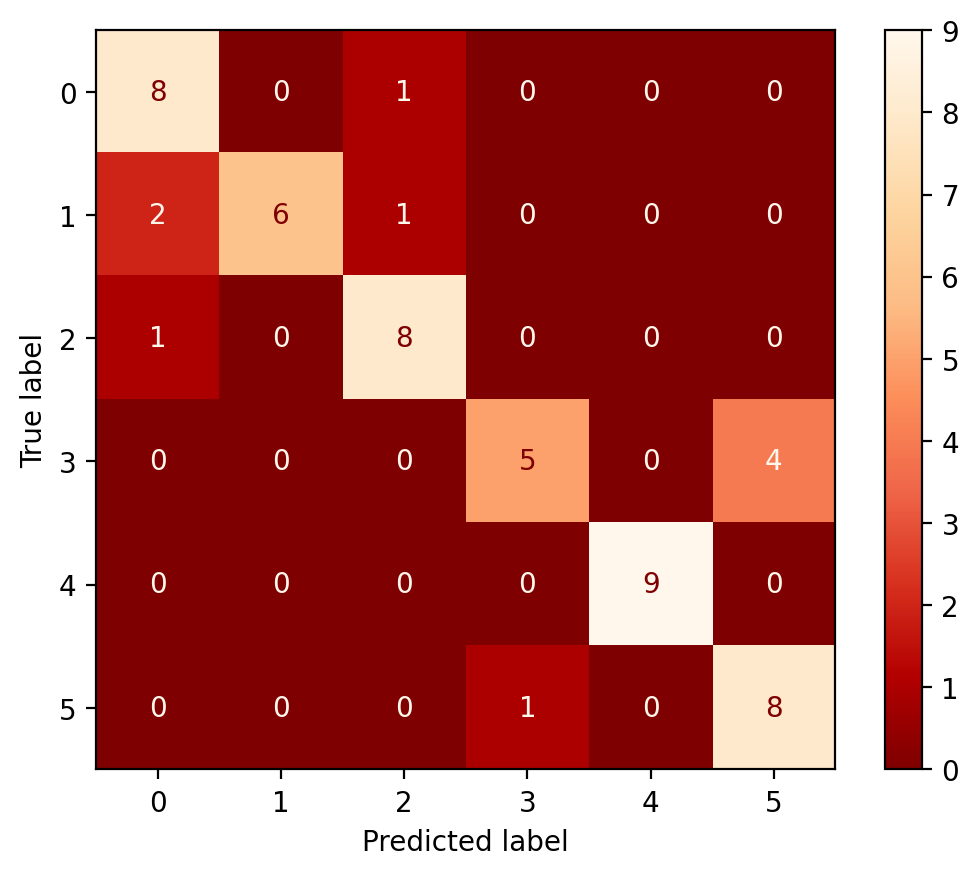

In [ ]:
clf_for_raw_data=DecisionTreeClassifier()

clf_for_raw_data.fit(x_train_tsfel_extracted_data, y_train)
y_pred=clf_for_raw_data.predict(x_test_tsfel_extracted_data)

accuracy=accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

cm = confusion_matrix(y_test, y_pred)
cm_display = ConfusionMatrixDisplay(cm).plot(values_format='d', cmap='OrRd_r', ax=plt.gca())
print(classification_report(y_test, y_pred))

* Train a decision tree model using the features provided in the dataset. Report the accuracy, precision, recall and confusion matrix of the model.

Accuracy: 0.8639294197488971
              precision    recall  f1-score   support

           1       0.83      0.93      0.87       496
           2       0.83      0.76      0.80       471
           3       0.86      0.82      0.84       420
           4       0.84      0.78      0.81       491
           5       0.81      0.87      0.84       532
           6       1.00      1.00      1.00       537

    accuracy                           0.86      2947
   macro avg       0.86      0.86      0.86      2947
weighted avg       0.86      0.86      0.86      2947



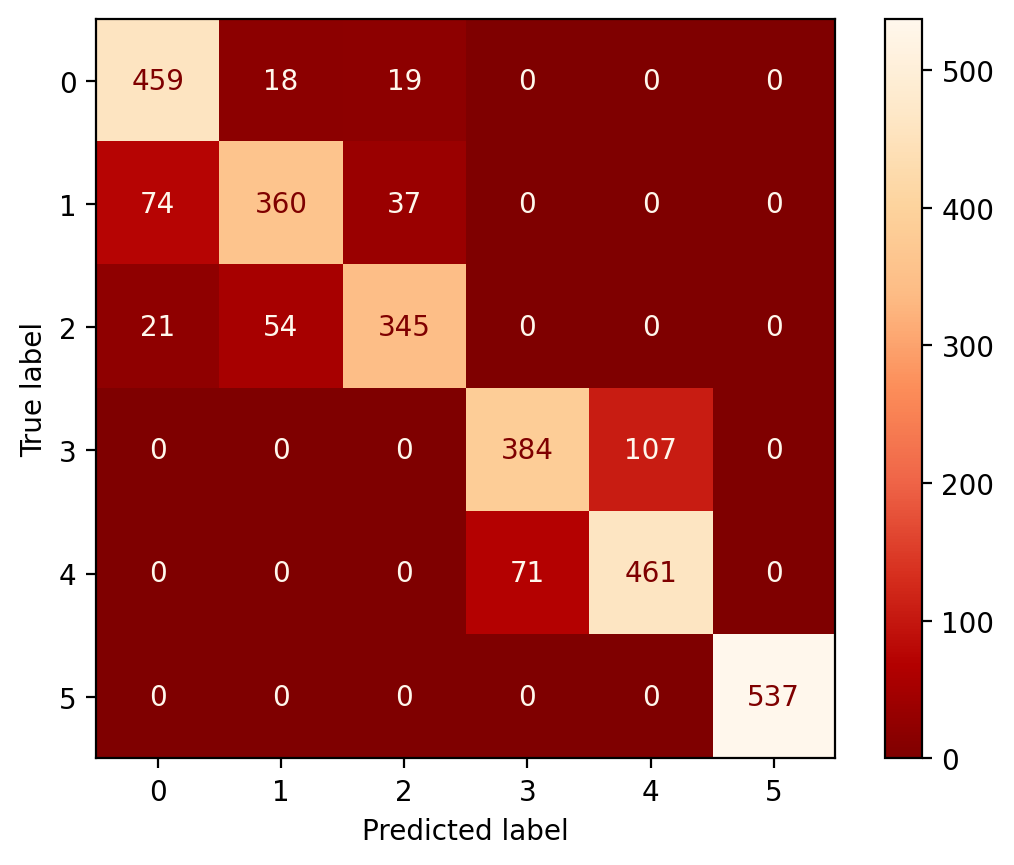

In [ ]:
import pandas as pd 

clf_for_dataset=DecisionTreeClassifier()

clf_for_dataset.fit(x_train_dataset,y_train_dataset)
y_pred=clf_for_dataset.predict(x_test_dataset)

accuracy=accuracy_score(y_test_dataset,y_pred)
print(f"Accuracy: {accuracy}")

cm = confusion_matrix(y_test_dataset, y_pred)
ConfusionMatrixDisplay(cm).plot(values_format='d', cmap='OrRd_r', ax=plt.gca())
print(classification_report(y_test_dataset, y_pred))

Using Leave one Subject out K-Fold validation

In [ ]:
def leave_one_subject_out_val(X_train, y_train, groups, cls):
    
    logo = LeaveOneGroupOut()
    Accuracy = []
    Precision = []
    Recall = []

    for i, (train_idx, val_idx) in enumerate(logo.split(X_train, y_train, groups)):

        cls.fit(X_train[train_idx], y_train[train_idx])
        y_pred = cls.predict(X_train[val_idx])
        Accuracy.append(accuracy_score(y_train[val_idx], y_pred))
        Precision.append(metrics.precision_score(y_train[val_idx], y_pred, average='weighted'))
        Recall.append(metrics.recall_score(y_train[val_idx], y_pred, average='weighted'))
                
    return Accuracy, Precision, Recall

clf = DecisionTreeClassifier()

Accuracy, Precision, Recall = leave_one_subject_out_val(np.array(x_train_dataset),  np.array(y_train_dataset).reshape(7352), np.array(groups).reshape(7352), clf)

Text(0.5, 1.0, 'Leave One Subject out')

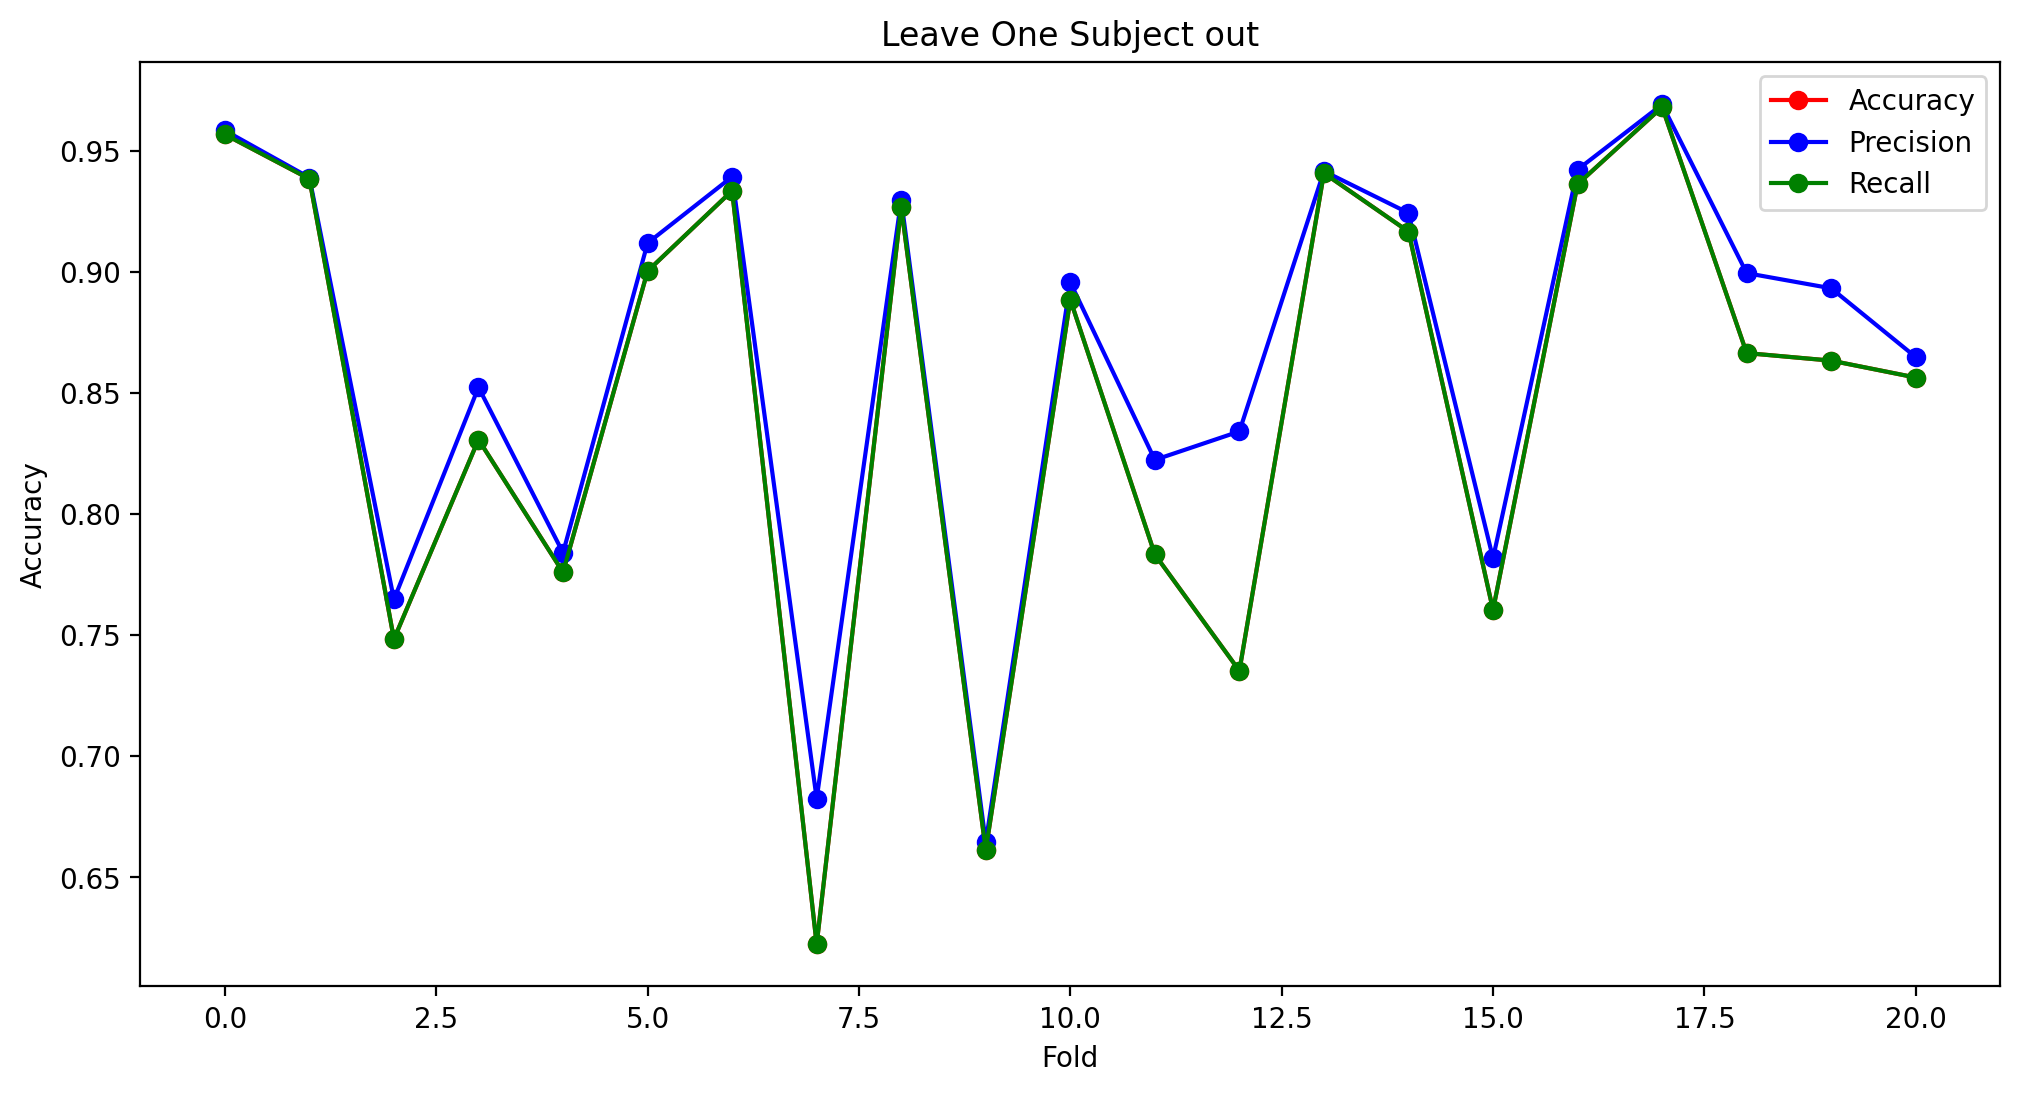

In [ ]:
fig, ax = plt.subplots(figsize=(12,6))

ax.plot(Accuracy, marker='o', label="Accuracy", color='r')
ax.plot(Precision, marker='o', label="Precision", color='b')
ax.plot(Recall, marker='o', label="Recall", color='g')

ax.set_xlabel("Fold")
ax.set_ylabel("Accuracy")
ax.legend(loc='best')
ax.set_title("Leave One Subject out")

#### Train Decision Tree with varying depths (2-8) using  above 3 methods. Plot the accuracy of the model on test data vs the depth of the tree. A Train a decision tree model using the raw accelerometer data. Report the accuracy, precision, recall and confusion matrix of the model.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

def get_accuracy(x_train, y_train, x_test, y_test, pca=None):

    accuracy_test = []
    accuracy_train = []

    for max_depth in range(2,9):

        decisiontreeclassifier = DecisionTreeClassifier(max_depth=max_depth)
        if pca is not None:
            x_train = pca.fit_transform(x_train)
            x_test = pca.transform(x_test)
        decisiontreeclassifier.fit(x_train, y_train)
        test_prediction = decisiontreeclassifier.predict(x_test)
        train_prediction = decisiontreeclassifier.predict(x_train)
        accuracy_test.append([max_depth, accuracy_score(test_prediction, y_test)])
        accuracy_train.append([max_depth, accuracy_score(train_prediction, y_train)])
        
    return accuracy_test, accuracy_train

Linear acceleration

Text(0.5, 1.0, 'RAW Data(Linear Acceleration)')

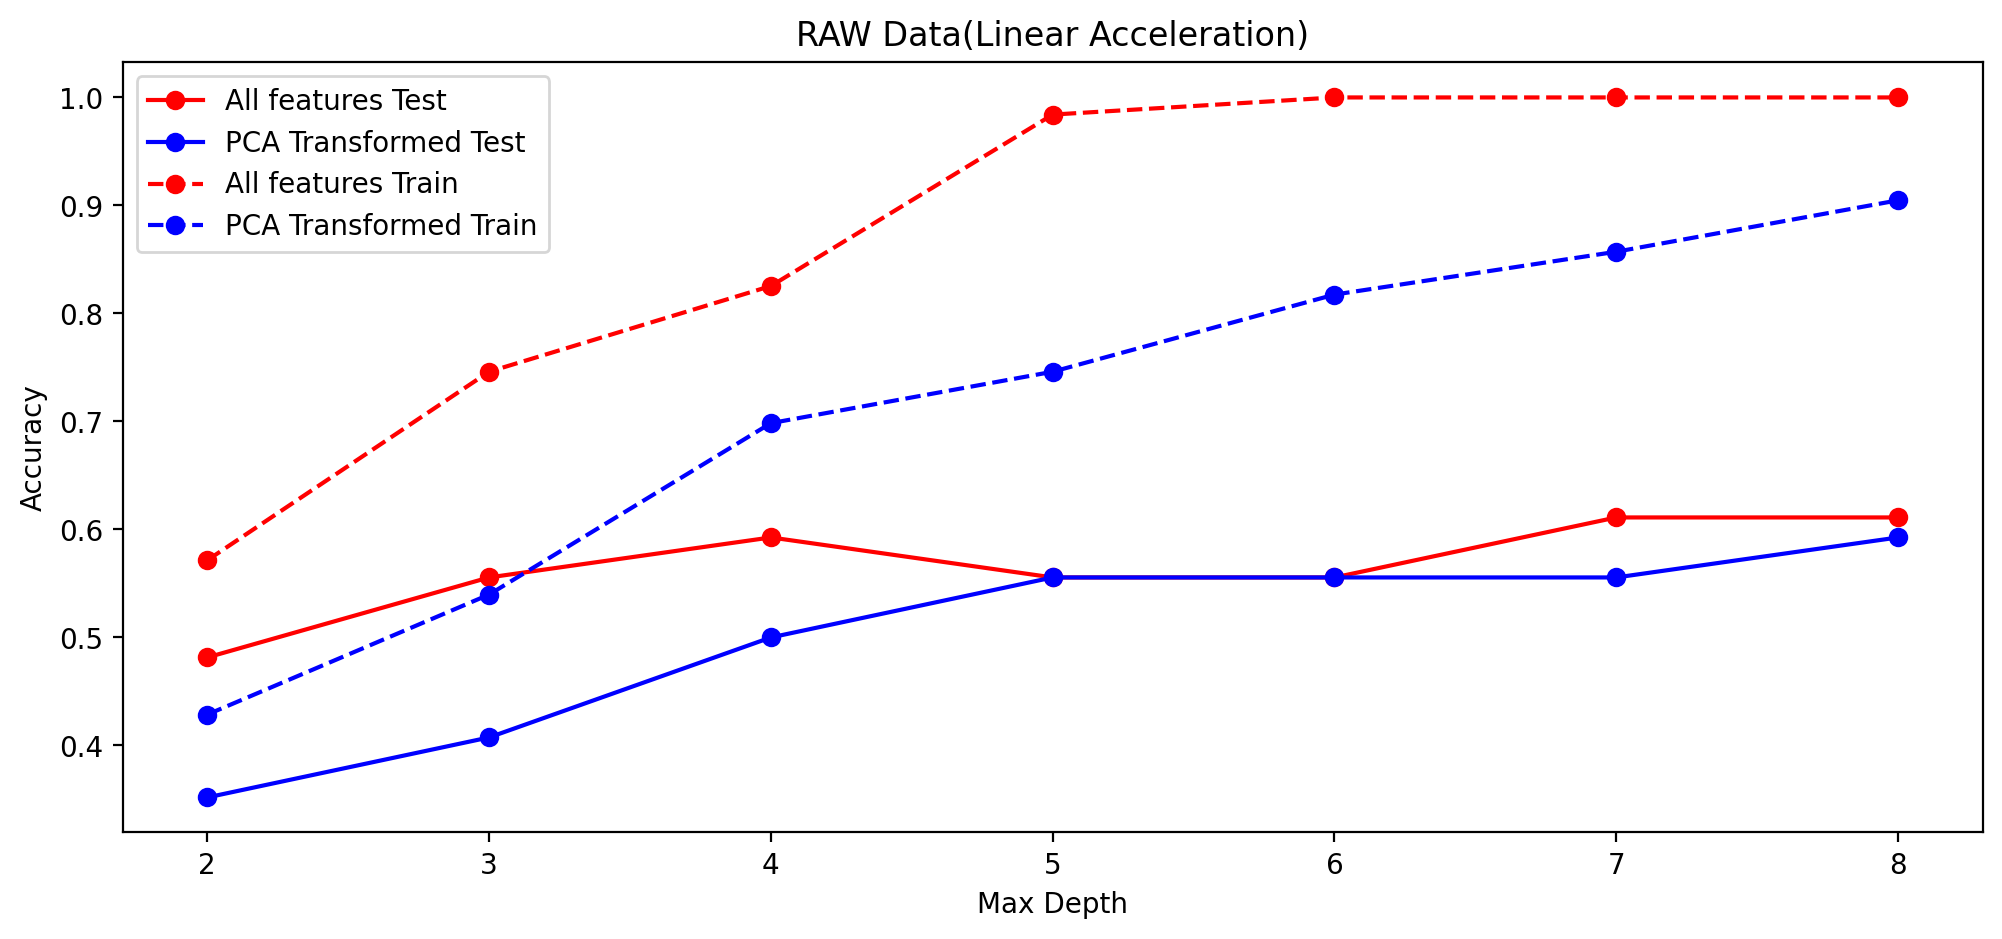

In [ ]:
Average_linear_acceleration_X_train = np.sum(np.square(X_train), axis=-1)
Average_linear_acceleration_X_test = np.sum(np.square(X_test), axis=-1)

accuracy_500_test, accuracy_500_train = np.array(get_accuracy(Average_linear_acceleration_X_train, y_train,Average_linear_acceleration_X_test, y_test))
accuracy_2_test, accuracy_2_train = np.array(get_accuracy(Average_linear_acceleration_X_train, y_train,Average_linear_acceleration_X_test, y_test, pca))


fig, ax = plt.subplots(figsize=(12,5))

ax.plot(accuracy_500_test.T[0], accuracy_500_test.T[1], marker='o', color='r', label="All features Test")
ax.plot(accuracy_2_test.T[0], accuracy_2_test.T[1], marker='o', color='b', label="PCA Transformed Test")
ax.plot(accuracy_500_train.T[0], accuracy_500_train.T[1], marker='o', color='r', label="All features Train", linestyle='--')
ax.plot(accuracy_2_train.T[0], accuracy_2_train.T[1], marker='o', color='b', label="PCA Transformed Train", linestyle='--')

ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy")
ax.legend(loc='best')
ax.set_title("RAW Data(Linear Acceleration)")

* TSFEL

Text(0.5, 1.0, 'TSFEL extracted Data')

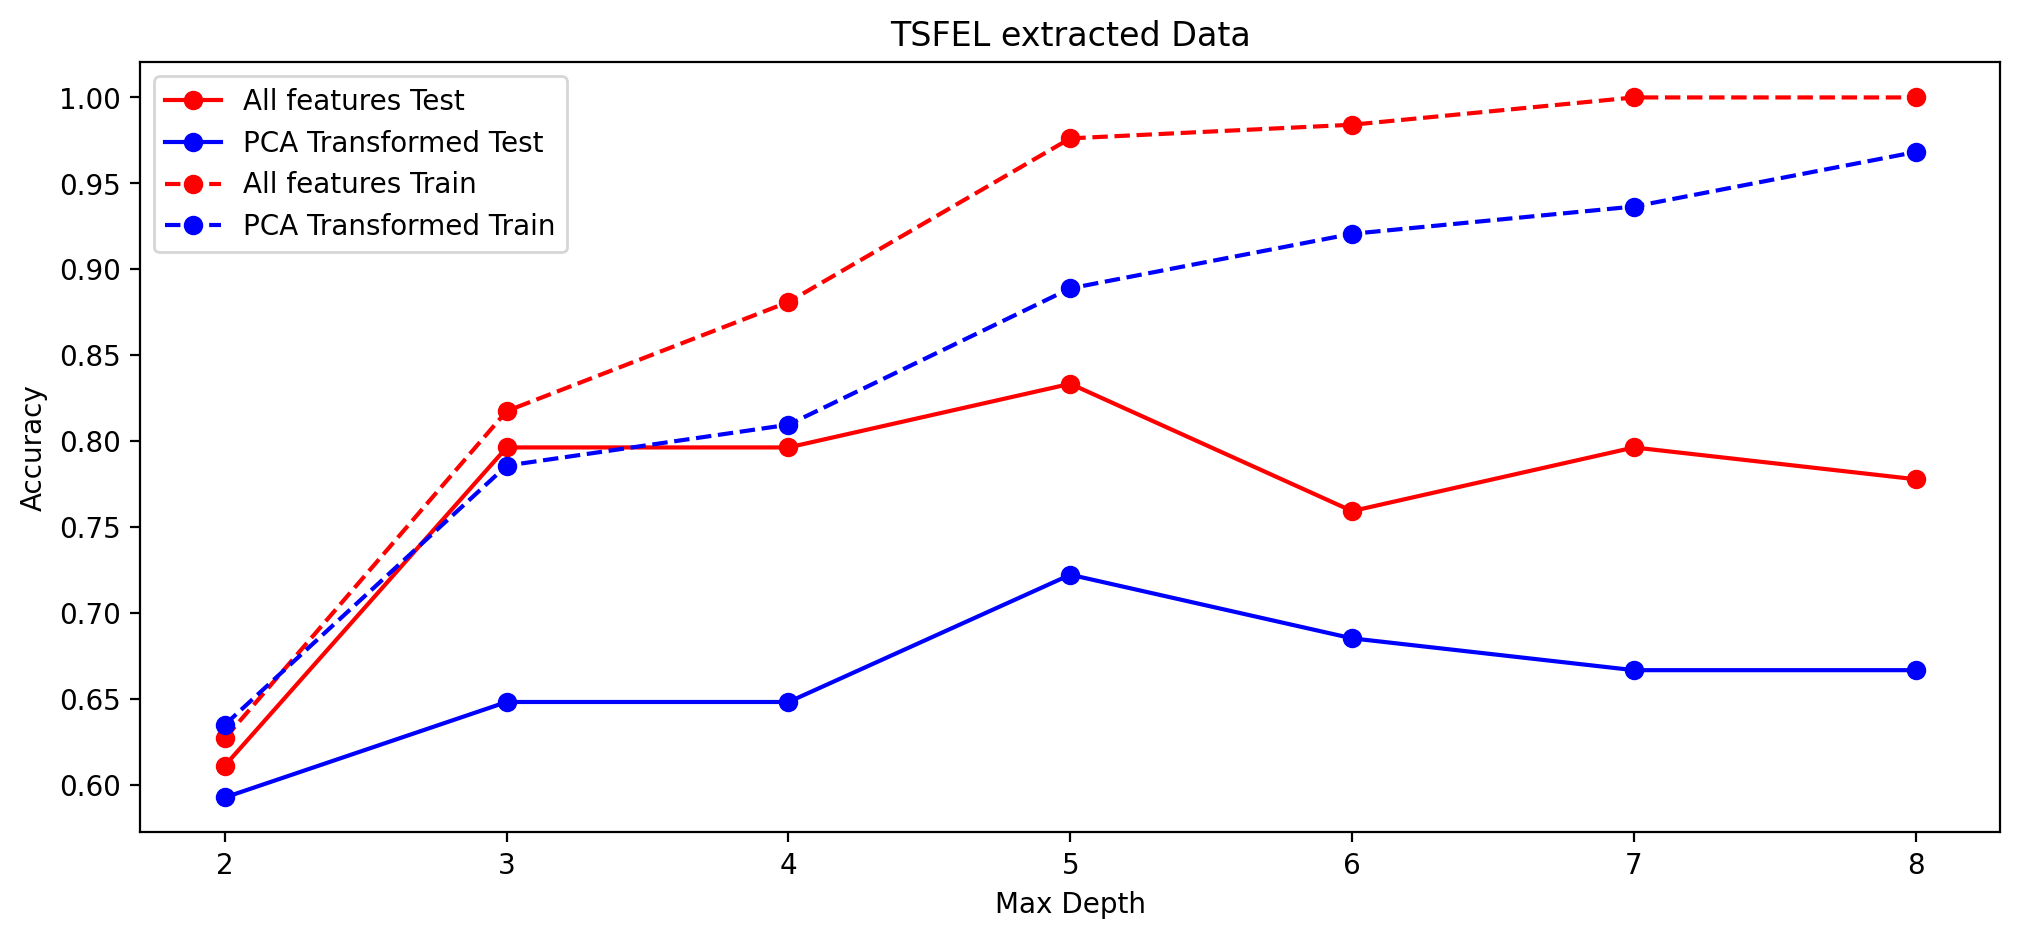

In [ ]:
accuracy_500_test,  accuracy_500_train= np.array(get_accuracy(x_train_tsfel_extracted_data, y_train, x_test_tsfel_extracted_data, y_test))
accuracy_2_test, accuracy_2_train = np.array(get_accuracy(x_train_tsfel_extracted_data, y_train, x_test_tsfel_extracted_data, y_test, pca))


fig, ax = plt.subplots(figsize=(12,5))

ax.plot(accuracy_500_test.T[0], accuracy_500_test.T[1], marker='o', color='r', label="All features Test")
ax.plot(accuracy_2_test.T[0], accuracy_2_test.T[1], marker='o', color='b', label="PCA Transformed Test")
ax.plot(accuracy_500_train.T[0], accuracy_500_train.T[1], marker='o', color='r', label="All features Train", linestyle='--')
ax.plot(accuracy_2_train.T[0], accuracy_2_train.T[1], marker='o', color='b', label="PCA Transformed Train", linestyle='--')

ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy")
ax.legend(loc='best')
ax.set_title("TSFEL extracted Data")

Featurd Dataset

Text(0.5, 1.0, 'With 561 Fetaures')

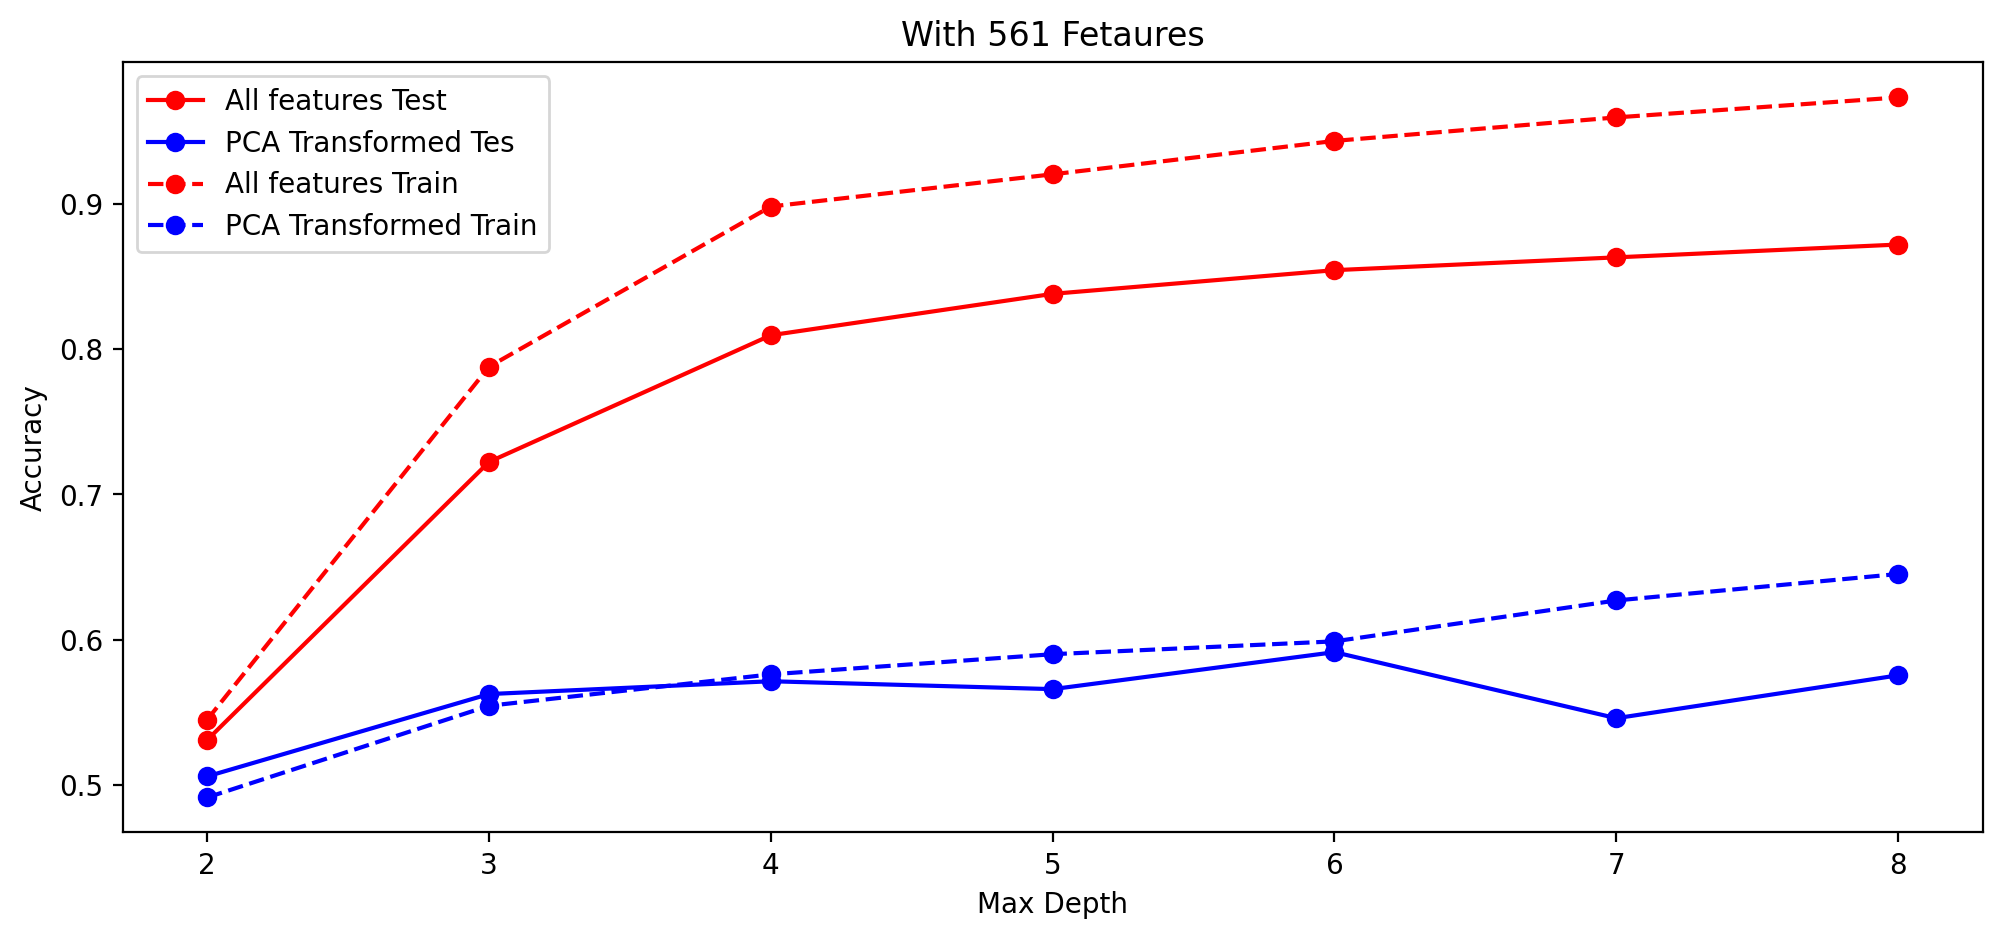

In [ ]:
accuracy_561_test, accuracy_561_train = np.array(get_accuracy(x_train_dataset, y_train_dataset, x_test_dataset, y_test_dataset))
accuracy_2_test, accuracy_2_train = np.array(get_accuracy(x_train_dataset, y_train_dataset, x_test_dataset, y_test_dataset, pca))


fig, ax = plt.subplots(figsize=(12,5))

ax.plot(accuracy_561_test.T[0], accuracy_561_test.T[1], marker='o', color='r', label="All features Test")
ax.plot(accuracy_2_test.T[0], accuracy_2_test.T[1], marker='o', color='b', label="PCA Transformed Tes")
ax.plot(accuracy_561_train.T[0], accuracy_561_train.T[1], marker='o', color='r', label="All features Train", linestyle='--')
ax.plot(accuracy_2_train.T[0], accuracy_2_train.T[1], marker='o', color='b', label="PCA Transformed Train", linestyle='--')

ax.set_xlabel("Max Depth")
ax.set_ylabel("Accuracy")
ax.legend(loc='best')
ax.set_title("With 561 Fetaures")

### Task 3

* Using Zero-Shot Learning and Few-Shot Learning to classify human activities based on the featurized accelerometer data. 

In [ ]:
examples_of_labels = {}

for i in np.unique(y_train_dataset):
    examples_of_labels[int(i)] = np.where(y_train_dataset == i)[0][:5]
examples_of_labels

{1: array([78, 79, 80, 81, 82], dtype=int64),
 2: array([150, 151, 152, 153, 154], dtype=int64),
 3: array([125, 126, 127, 128, 129], dtype=int64),
 4: array([27, 28, 29, 30, 31], dtype=int64),
 5: array([0, 1, 2, 3, 4], dtype=int64),
 6: array([51, 52, 53, 54, 55], dtype=int64)}

In [ ]:
import pandas as pd 
from langchain_groq.chat_models import ChatGroq
import dotenv
import os
dotenv.load_dotenv()
Groq_Token = os.environ.get("GROQ_API_KEY")
#Groq_Token ="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"

if not Groq_Token:
    print("API Key not found! Make sure it's set correctly in your .env file.")
else:
    print("API Key loaded successfully.")

groq_models = {"llama3-70b": "llama3-70b-8192", "mixtral": "mixtral-8x7b-32768", "gemma-7b": "gemma-7b-it","llama3.1-70b":"llama-3.1-70b-versatile","llama3-8b":"llama3-8b-8192","llama3.1-8b":"llama-3.1-8b-instant","gemma-9b":"gemma2-9b-it"}

API Key loaded successfully.


In [ ]:
def zero_shot(X_train, y_train, X_test, y_test, pos):
    
    query = f"""
    * You are a Human Actitvity detection model. 
    * Your task is to classifiy the movement BASED ON DATA into 6 category WALKING - 1,
    CLIMBING UP THE STAIRS - 2, CLIMBING DOWN THE STAIRS - 3, SITTING - 4, STANDING - 5, LAYING - 6 . 
    * You will be provided time series sensor data that will have data for features
    * Just print 'The above movement is of class x WHERE X RANGE  FROM 1 TO 6.'

    Data: {X_test.iloc[pos]}
    """ 

    model_name = "llama3-70b"
    llm = ChatGroq(model=groq_models[model_name], api_key=Groq_Token, temperature=0)
    answer = llm.invoke(query)

    print(answer.content)

    print(f"Actuall Label is {y_test.iloc[pos].values[0]}\n")

def few_shot(X_train, y_train, X_test, y_test, pos):

    query = f"""
        * You are a Human Actitvity detection model. 
        * Your task is to classifiy the movement into 6 category WALKING - 1,
        CLIMBING UP THE STAIRS - 2, CLIMBING DOWN THE STAIRS - 3, SITTING - 4, STANDING - 5, LAYING - 6 . 
        * You will be provided series of sensor data with 561 features.
        * Just print 'The above movement is of class x.'

        Here are some example:
        1. {X_train.iloc[78]}: output: The above movement is of class 1
        2. {X_train.iloc[79]}: output: The above movement is of class 1
        3. {X_train.iloc[150]}: output: The above movement is of class 2
        4. {X_train.iloc[151]}: output: The above movement is of class 2
        5. {X_train.iloc[125]}: output: The above movement is of class 3
        6. {X_train.iloc[126]}: output: The above movement is of class 3
        7. {X_train.iloc[27]}: output: The above movement is of class 4
        8. {X_train.iloc[28]}: output: The above movement is of class 4
        9. {X_train.iloc[1]}: output: The above movement is of class 5
        10. {X_train.iloc[2]}: output: The above movement is of class 5
        11. {X_train.iloc[51]}: output: The above movement is of class 6
        12. {X_train.iloc[52]}: output: The above movement is of class 6

    Sentence: {str(X_test.iloc[pos])}
    """

    model_name = "llama3-70b"
    llm = ChatGroq(model=groq_models[model_name], api_key=Groq_Token, temperature=0)
    answer = llm.invoke(query)

    print(answer.content)
    print(f"Actuall Label is {y_test.iloc[pos].values}\n")

BOLD = '\033[1m'
RESET = '\033[0m'

for func in [zero_shot, few_shot]:
    print(BOLD, '\t'*6,'*'*3,func.__name__,'*'*3, RESET)
    for pos in np.random.randint(0,560,5):
        print("*"*20)
        func(x_train_dataset, y_train_dataset, x_test_dataset, y_test_dataset, pos)


 						 *** zero_shot *** 
********************
The above movement is of class 1.
Actuall Label is 6

********************
The above movement is of class 1.
Actuall Label is 4

********************
The above movement is of class 1.
Actuall Label is 6

********************
The above movement is of class 1.
Actuall Label is 4

********************
The above movement is of class 2.
Actuall Label is 2

 						 *** few_shot *** 
********************
The above movement is of class 5.
Actuall Label is [5]

********************
The above movement is of class 5.
Actuall Label is [6]

********************
The above movement is of class 1.
Actuall Label is [2]

********************
The above movement is of class 1.
Actuall Label is [5]

********************
The above movement is of class 5.
Actuall Label is [6]



* compare the accuracy of Few-Shot Learning with Decision Trees

In [ ]:
def fewshot2(X_train, X_test, pos):

    query = f"""
        * You are a Human Actitvity detection model. 
        * Your task is to classifiy the movement into 6 category WALKING - 1,
        CLIMBING UP THE STAIRS - 2, CLIMBING DOWN THE STAIRS - 3, SITTING - 4, STANDING - 5, LAYING - 6 . 
        *based on data you predict labels from 1 to 6 in output Just print x where x range from 1 to 6.
        * please be sure that in result you only gave numbers from 1 to 6 nothing else

        Here are some example:
        1. {X_train.iloc[78]}: output: The above movement is of class 1
        2. {X_train.iloc[79]}: output: The above movement is of class 1
        3. {X_train.iloc[150]}: output: The above movement is of class 2
        4. {X_train.iloc[151]}: output: The above movement is of class 2
        5. {X_train.iloc[125]}: output: The above movement is of class 3
        6. {X_train.iloc[126]}: output: The above movement is of class 3
        7. {X_train.iloc[27]}: output: The above movement is of class 4
        8. {X_train.iloc[28]}: output: The above movement is of class 4
        9. {X_train.iloc[1]}: output: The above movement is of class 
        10. {X_train.iloc[2]}: output: The above movement is of class 5
        11. {X_train.iloc[51]}: output: The above movement is of class 6
        12. {X_train.iloc[52]}: output: The above movement is of class 6

    Sentence: {X_test.iloc[int(pos)]}
    """ 

    model_name = "llama3-70b"
    llm = ChatGroq(model=groq_models[model_name], api_key=Groq_Token, temperature=0)
    answer = llm.invoke(query)
    return int(answer.content.strip())

In [ ]:
few_shot_pred=[]
test_idx = np.random.randint(0,2947,100)
y_true = np.array(y_test_dataset)[test_idx]
dt_clf_pred = clf_for_dataset.predict(np.array(x_test_dataset)[test_idx])
dt_accuracy = accuracy_score(y_true.reshape(100), dt_clf_pred)
dt_accuracy

0.93

In [ ]:

test_idx = np.random.randint(0,2947,10)
few_shot_pred=[]
for pos in test_idx:
    pred=fewshot2(x_train_dataset, x_test_dataset, pos) 
    few_shot_pred.append(pred)
y_true = np.array(y_test_dataset)[test_idx]     
few_shot_accuracy = accuracy_score(y_true, few_shot_pred)
few_shot_accuracy


0.4

* Model classification when given input from an entirely new activity that it hasn't seen before

In [ ]:
def fewshot3(X_train, pos):

    query = f"""
        * You are a Human Actitvity detection model. 
        * Your task is to classifiy the movement into 6 category WALKING - 1,
        CLIMBING UP THE STAIRS - 2, CLIMBING DOWN THE STAIRS - 3, SITTING - 4, STANDING - 5, LAYING - 6 . 
        *based on data you predict labels from 1 to 6 in output Just print x where x range from 1 to 6.
        * please be sure that in result you only gave numbers from 1 to 6 nothing else

        Here are some example:
        1. {X_train.iloc[78]}: output: The above movement is of class 1
        2. {X_train.iloc[79]}: output: The above movement is of class 1
        3. {X_train.iloc[150]}: output: The above movement is of class 2
        4. {X_train.iloc[151]}: output: The above movement is of class 2
        5. {X_train.iloc[125]}: output: The above movement is of class 3
        6. {X_train.iloc[126]}: output: The above movement is of class 3
        7. {X_train.iloc[27]}: output: The above movement is of class 4
        8. {X_train.iloc[28]}: output: The above movement is of class 4
        9. {X_train.iloc[1]}: output: The above movement is of class 5
        10. {X_train.iloc[2]}: output: The above movement is of class 5

    Sentence: {X_train.iloc[int(pos)]}
    """ 

    model_name = "llama3-70b"
    llm = ChatGroq(model=groq_models[model_name], api_key=Groq_Token, temperature=0)
    answer = llm.invoke(query)

    print(answer.content)
    print(f"Actuall Label is {y_test[pos]}\n")

for pos in np.where(y_test==6)[0]:
    fewshot3(x_train_dataset, int(pos))

5
Actuall Label is 6

5
Actuall Label is 6

1
Actuall Label is 6

5
Actuall Label is 6

5
Actuall Label is 6

4
Actuall Label is 6

5
Actuall Label is 6

5
Actuall Label is 6

6
Actuall Label is 6

